In [5]:
%matplotlib widget

from matplotlib import pyplot as plt
import numpy as np
import scipy.integrate as integrate
import matplotlib.animation as animation
from functools import partial
import control as ct

C:\Users\gertv\AppData\Local\Temp\ipykernel_19128\3969226528.py:122: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(


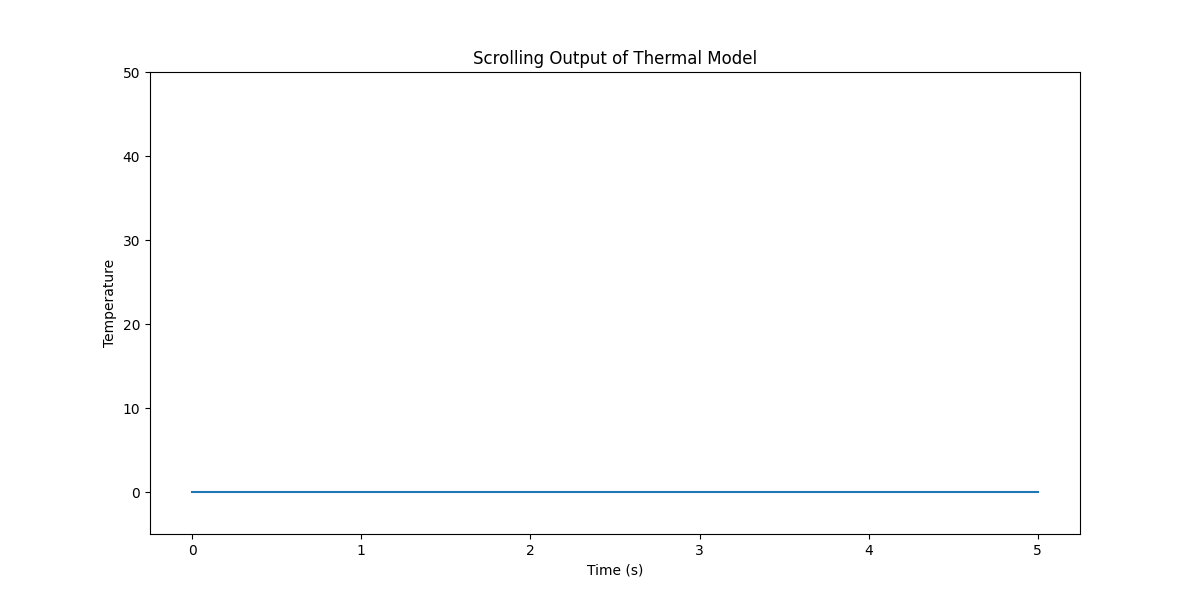

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy import integrate

ani = None
window_length = 5     # seconds
dt = 0.1              # seconds

  
class Past_inputs_anim:
    """
    Animates the output of a dynamic model over a moving time window.
    Uses solve_ivp for full model flexibility.
    """

    def __init__(self, line, ax, model_function, window_length=10, dt=0.1):

        self.line = line
        self.ax = ax
        self.model_function = model_function

        self.dt = dt
        self.window_samples = int(window_length / dt)
        self.N = self.window_samples

        self.history = np.zeros(self.N)
        self.ptr = 0

        self.state = np.array([20.0])  # initial state (must be array for solve_ivp)
        self.current_time = 0.0

    def init_plot(self):
        self.line.set_ydata(np.zeros(self.N))
        return self.line,

    def step(self, u):
        """
        Advances system by one dt using solve_ivp.
        Keeps implementation fully general.
        """

        # Define constant input over this step
        def u_func(t):
            return u

        sol = integrate.solve_ivp(
            self.model_function,
            [self.current_time, self.current_time + self.dt],
            self.state,
            args=(u_func,),                   # pass input function
            t_eval=[self.current_time + self.dt]
        )

        self.current_time += self.dt
        self.state = sol.y[:, -1]            # works for multi-state systems

        return self.state[0]                 # assuming 1 state for plotting

    def update_history(self, u):

        output = self.step(u)

        self.history[self.ptr] = output
        self.ptr = (self.ptr + 1) % self.N

        # Chronological order reconstruction
        y_full = np.concatenate(
            (self.history[self.ptr:], self.history[:self.ptr])
        )

        return y_full

    def animate(self, i):

        # Example time-varying input
        u = 10 * np.sin(0.5 * self.current_time)**2

        y_window = self.update_history(u)

        x_window = np.linspace(
            self.current_time - len(y_window)*self.dt,
            self.current_time,
            len(y_window)
        )

        self.line.set_data(x_window, y_window)
        self.ax.set_xlim(x_window[0], x_window[-1])

        return self.line,


def run_animation(model_function, window_length=5, dt=0.1):

    global ani

    if ani is not None:
        ani.event_source.stop()

    plt.close("all")

    fig, ax = plt.subplots(figsize=(12, 6))

    line, = ax.plot(
        np.linspace(0, window_length, int(window_length/dt)),
        np.zeros(int(window_length/dt))
    )

    ax.set_ylim(-5, 50)
    ax.set_title("Scrolling Output of Thermal Model")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Temperature")

    state = Past_inputs_anim(
        line,
        ax,
        model_function,
        window_length=window_length,
        dt=dt
    )

    ani = animation.FuncAnimation(
        fig,
        state.animate,
        init_func=state.init_plot,
        interval=int(dt*1000),
        blit=True
    )

    plt.show()



# Example flexible model (expects u_func)
def firstOrderThermalModel(t, T, u_func, U_a=0.1, C_p=1.0, P_1=1.0):

    u = u_func(t)
    dTdt = -U_a/C_p * T + P_1/C_p * u

    return dTdt

    
# Run animation
run_animation(firstOrderThermalModel)

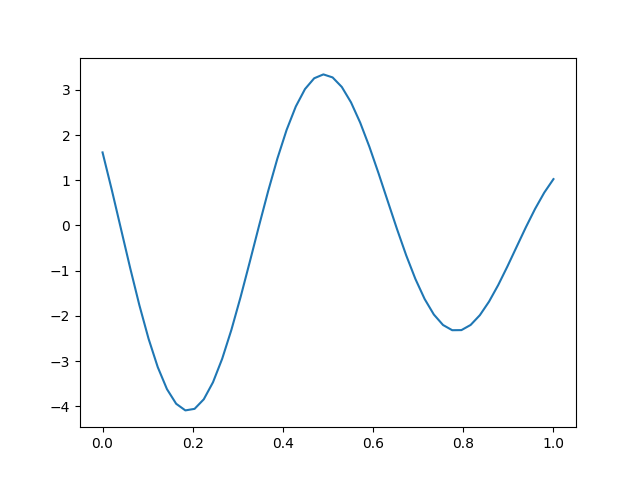

In [20]:
G = ct.rss(4)

time_pts = np.linspace(0, 1)
inputs = np.sin(time_pts)
y_0 = 1
t_out, y_out = ct.forced_response(G, time_pts, inputs, y_0)

plt.close()
plt.plot(t_out, y_out)
plt.show()